# TP Integrado — Laboratorio de Métodos Cuantitativos Aplicados a la Gestión

*Dataset: Superstore*

*Pregunta de investigación:* ¿Existe un nivel de descuento a partir del cual el incremento en ventas deja de compensar la reducción del margen de ganancia, provocando una disminución significativa de la rentabilidad de la empresa?

*Suposiciones esenciales:* Los datos de ventas están presentados en dolares.

# IMPORTS

In [103]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.float_format", lambda x: "%.2f" % x)

# 3.1. CARGA Y EXPLORACIÓN INICIAL

In [104]:


url_dataset = "https://raw.githubusercontent.com/Pitiki10/TP-GRUPAL---SuperStore/main/data/superstore.csv"
df = pd.read_csv(url_dataset, encoding="latin1")

print("=" * 70)
print("I. ESTRUCTURA Y TIPOS DE DATOS DEL DATASET (Método .info())")
print("=" * 70)
df.info()

print("" + "-" * 70 + "")

print("=" * 70)
print("II. ESTADÍSTICA DESCRIPTIVA DE VARIABLES NUMÉRICAS (Método .describe())")
print("=" * 70)
print(df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().round(3))
print("=" * 70)

# Verificación de valores nulos en columnas clave
print("Valores nulos por columna clave:")
print(df[['Sales', 'Profit', 'Discount', 'Quantity']].isnull().sum())

# Eliminación de duplicados (precaución)
antes = len(df)
df.drop_duplicates(inplace=True)
print(f"Registros eliminados por duplicado: {antes - len(df)}")
print(f"Registros totales: {len(df):,} | Columnas: {df.shape[1]}")

I. ESTRUCTURA Y TIPOS DE DATOS DEL DATASET (Método .info())
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sal

## 3.2. Pregunta de investigación

**¿Existe un nivel de descuento a partir del cual el incremento en las ventas deja de compensar la reducción del margen de ganancia, provocando una disminución significativa de la rentabilidad de la empresa?**

*¿Por qué vale la pena responderla?*

**Los descuentos son una de las herramientas comerciales más utilizadas para aumentar las ventas y atraer clientes. Sin embargo, una estrategia de descuentos excesivos puede generar un aumento en el volumen vendido sin traducirse en mayores beneficios económicos. Comprender la relación entre descuento y rentabilidad permite identificar prácticas comerciales eficientes, detectar niveles de descuento potencialmente perjudiciales y contribuir a una mejor toma de decisiones en materia de precios y promociones.**

*¿Qué respuesta encontramos?* 

**Encontramos que el EDA realizado durante el trabajo confirma nuestra hipotesis y logra contestar la pregunta del trabajo, a través del analisi económico de las funciones creadas a partir de la regresión. En pocas palabras, si hay un punto donde el nivel de descuento lleva a una baja del beneficio por debajo del 0, es decir, a la perdida. Ese punto exacto es 15.77% de descuento.**

# 3.3. TRANSFORMACIONES Y RESUMEN ESTADÍSTICO

# Transformación 1: Tramos de descuento

*Se agrupan los valores continuos de Discount en intervalos para facilitar la comparación entre grupos y detectar el umbral de pérdida de rentabilidad.*

In [105]:

bins   = [0, 0.05, 0.15, 0.25, 0.35, 0.50, 0.80]
labels = ['0–5%', '5–15%', '15–25%', '25–35%', '35–50%', '50–80%']

df['Tramo_descuento'] = pd.cut(
    df['Discount'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("Distribución de registros por tramo de descuento:")
print(df['Tramo_descuento'].value_counts().sort_index())


Distribución de registros por tramo de descuento:
Tramo_descuento
0–5%      4798
5–15%      146
15–25%    3657
25–35%     254
35–50%     283
50–80%     856
Name: count, dtype: int64


# Transformación 2: Margen de rentabilidad (ratio 0–1)

 *Profit / Sales mide qué proporción de cada venta se convierte en ganancia, permitiendo comparar operaciones de distinto tamaño de manera homogénea.*

In [106]:
df['Margen'] = df['Profit'] / df['Sales']

print("Estadísticas del Margen de rentabilidad:")
print(df['Margen'].describe().round(4))

Estadísticas del Margen de rentabilidad:
count   9994.00
mean       0.12
std        0.47
min       -2.75
25%        0.07
50%        0.27
75%        0.36
max        0.50
Name: Margen, dtype: float64


# Transformación 3: Costo estimado 


*Costo_estimado = Sales - Profit permite modelizar la curva de costos. Esto será clave más adelante, ya que podremos ver como se relaciona con el Ingreso y por ende ver el beneficio y su comportamiento.*

In [107]:
df['Costo_estimado'] = df['Sales'] - df['Profit']

# Visualización del dataset con las modificaciónes realizadas

In [108]:
df.head(5)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Tramo_descuento,Margen,Costo_estimado
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,0–5%,0.16,220.05
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,0–5%,0.30,512.36
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,0–5%,0.47,7.75
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,35–50%,-0.40,1340.61
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,15–25%,0.11,19.85


# Estadístico de resumen 1: Profit promedio por categoría y tramo de descuento

*Permite identificar si el efecto de los descuentos sobre la rentabilidad es uniforme entre categorías o si algunas son más sensibles que otras.*

In [109]:
profit_por_categoria = (
    df.groupby(['Category', 'Tramo_descuento'], observed=True)['Profit']
    .mean()
    .round(2)
    .reset_index()
    .sort_values(['Category', 'Tramo_descuento'])
)

print("Profit promedio por categoría y tramo de descuento:")
print(profit_por_categoria.to_string(index=False))

Profit promedio por categoría y tramo de descuento:
       Category Tramo_descuento  Profit
      Furniture            0–5%   69.54
      Furniture           5–15%   66.64
      Furniture          15–25%   10.19
      Furniture          25–35%  -52.56
      Furniture          35–50% -225.37
      Furniture          50–80%  -64.31
Office Supplies            0–5%   41.71
Office Supplies           5–15%   67.88
Office Supplies          15–25%   17.28
Office Supplies          50–80%  -69.32
     Technology            0–5%  158.88
     Technology           5–15%  416.04
     Technology          15–25%   54.74
     Technology          25–35%   65.21
     Technology          35–50% -101.43
     Technology          50–80% -851.27


# Estadístico de resumen 2: Tabla resumen por tramo de descuento (Sin filtrar)

*Esta tabla concentra en una las métricas clave que se utilizarán los gráficos exploratorios.*


In [110]:
resumen_tramo = (
    df.groupby('Tramo_descuento', observed=True, as_index=False)
    .agg(
        Ventas_prom   = ('Sales',                'mean'),
        Profit_prom   = ('Profit',               'mean'),
        Costo_prom    = ('Costo_estimado',       'mean'),
        Margen_prom   = ('Margen',               'mean'),
        Cantidad_prom = ('Quantity',             'mean'), # ¡Ojo! Gráfico 3 necesita esto
        N             = ('Sales',                'count')
    )
)

print("Resumen por tramo de descuento (Para Gráficos EDA):")
print(resumen_tramo.to_string(index=False))
print("\n" + "="*70 + "\n")

Resumen por tramo de descuento (Para Gráficos EDA):
Tramo_descuento  Ventas_prom  Profit_prom  Costo_prom  Margen_prom  Cantidad_prom    N
           0–5%       226.74        66.90      159.84         0.34           3.81 4798
          5–15%       561.15        71.56      489.59         0.11           3.91  146
         15–25%       209.08        24.70      184.37         0.18           3.74 3657
         25–35%       463.47       -50.24      513.70        -0.12           3.76  254
         35–50%       638.94      -162.74      801.69        -0.31           3.79  283
         50–80%        75.03       -89.44      164.47        -1.14           3.91  856




# Estadístico de resumen 3: Tabla resumen por tramo de descuento (Filtrada)

*Esta tabla concentra en una las métricas clave que se utilizarán en el modelado economico núcleo de este analisis y sus gráficos correspondientes.*


*Calculamos los límites para descartar el 5% más extremo (2.5% de cada lado)*

In [111]:

limite_inferior = df['Profit'].quantile(0.025)
limite_superior = df['Profit'].quantile(0.975)

*Creamos un nuevo dataframe sin esos valores extremos*

In [112]:
df_limpio = df[(df['Profit'] >= limite_inferior) & (df['Profit'] <= limite_superior)].copy()
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Tramo_descuento,Margen,Costo_estimado
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,0–5%,0.16,220.05
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,0–5%,0.30,512.36
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,0–5%,0.47,7.75
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,35–50%,-0.40,1340.61
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,15–25%,0.11,19.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.25,3,0.20,4.10,15–25%,0.16,21.15
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2,0.00,15.63,0–5%,0.17,76.33
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.58,2,0.20,19.39,15–25%,0.07,239.18
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4,0.00,13.32,0–5%,0.45,16.28


*Ahora sí generamos la tabla*

In [113]:
resumen = (
    df_limpio.groupby('Discount', as_index=False) 
    .agg(
        Ventas_prom = ('Sales',            'mean'),
        Profit_prom = ('Profit',           'mean'),
        Costo_prom  = ('Costo_estimado',   'mean'),
        Margen_prom = ('Margen',           'mean'),
        N           = ('Sales',            'count')
    )
    .sort_values('Discount')
)
resumen

,Discount,Ventas_prom,Profit_prom,Costo_prom,Margen_prom,N
0,0.00,142.95,36.75,106.20,0.34,4611
1,0.10,405.36,66.15,339.21,0.15,87
2,0.15,529.97,27.29,502.68,0.03,52
3,0.20,168.57,16.75,151.82,0.18,3579
4,0.30,403.24,-31.67,434.91,-0.11,208
5,0.32,365.89,-47.65,413.54,-0.16,22
6,0.40,274.80,-34.03,308.83,-0.19,152
7,0.45,232.61,-100.94,333.56,-0.45,4
8,0.50,188.06,-58.87,246.93,-0.48,26
9,0.60,29.38,-21.13,50.51,-0.65,126


# Interpretación:


 **A medida que aumenta el tramo de descuento, el margen promedio disminuye de forma sostenida. Los descuentos en los tramos más altos presentan  márgenes negativos, lo que sugiere que el incremento en ventas no compensa la reducción de ganancias provocada por la política de descuentos.**

# 3.4. ANÁLISIS GRÁFICO

# Gráfico 1: Comportamiento por tramo (Ventas, Profit, Margen)

*Panorama general del impacto de los descuentos en las tres métricas clave.*

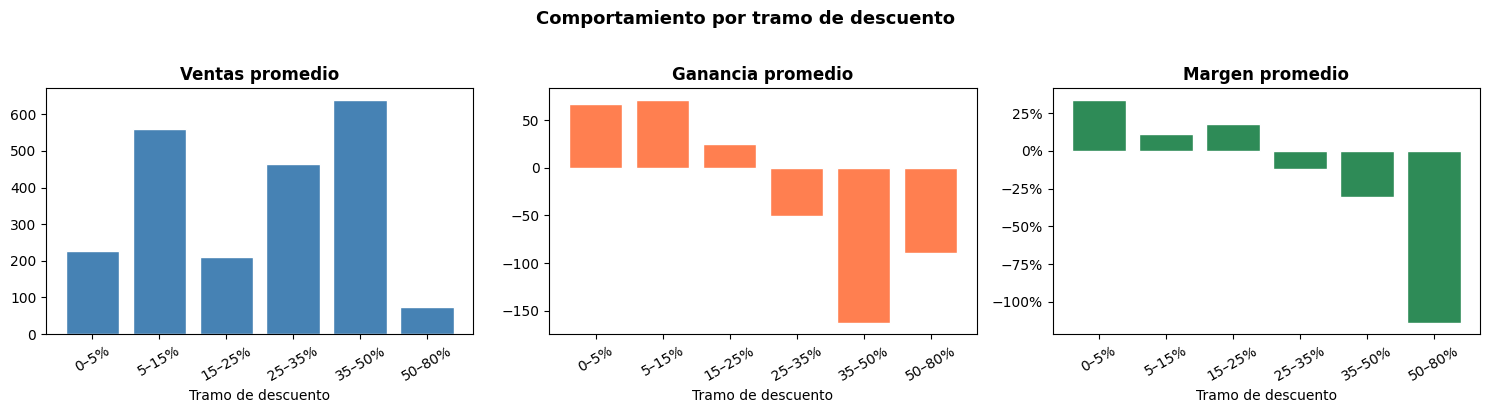

In [114]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = ['Ventas_prom', 'Profit_prom', 'Margen_prom']
titulos  = ['Ventas promedio', 'Ganancia promedio', 'Margen promedio']
colores  = ['steelblue', 'coral', 'seagreen']

for ax, met, tit, col in zip(axes, metricas, titulos, colores):
    ax.bar(
        resumen_tramo['Tramo_descuento'].astype(str),
        resumen_tramo[met],
        color=col,
        edgecolor='white'
    )
    ax.set_title(tit, fontweight='bold')
    ax.set_xlabel('Tramo de descuento')
    ax.tick_params(axis='x', rotation=30)
    if met == 'Margen_prom':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.suptitle('Comportamiento por tramo de descuento', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



# Interpretación:

**Las ventas promedio crecen hasta el tramo 15–25% y luego oscilan sin tendencia clara. La ganancia promedio cae de forma continua y se vuelve negativa en los tramos altos. El margen desciende sostenidamente, pasando de valores positivos en descuentos bajos a negativos en descuentos altos. Esto valida la necesidad de encontrar el punto de quiebre exacto.**

# Gráfico 2: Profit promedio por año y tramo de descuento

*Verifica si el patrón de caída del profit con descuentos altos es consistente a lo largo del tiempo y no es un artefacto de un año puntual.*

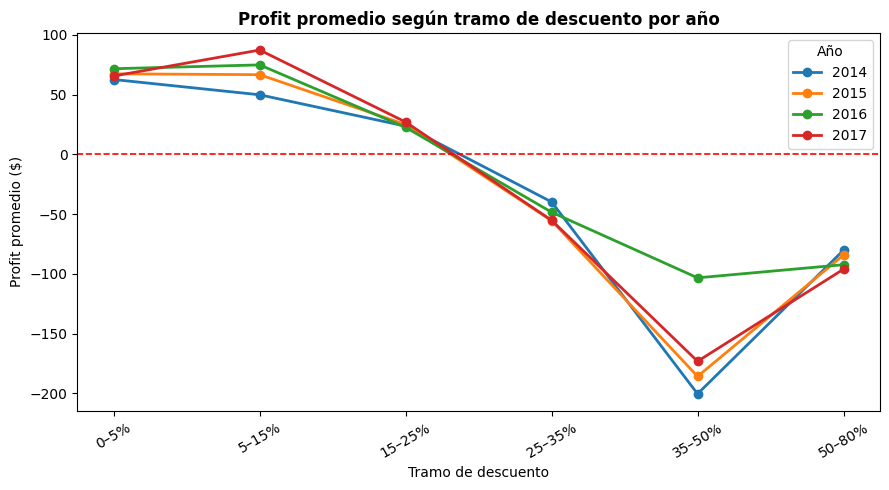

In [115]:

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Año'] = df['Order Date'].dt.year

profit_anio = (
    df.groupby(['Año', 'Tramo_descuento'], observed=True)['Profit']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

for anio in sorted(profit_anio['Año'].unique()):
    datos = profit_anio[profit_anio['Año'] == anio]
    plt.plot(
        datos['Tramo_descuento'].astype(str),
        datos['Profit'],
        marker='o',
        label=str(anio),
        linewidth=2
    )

plt.axhline(0, color='red', linestyle='--', linewidth=1.2)
plt.title('Profit promedio según tramo de descuento por año', fontweight='bold')
plt.xlabel('Tramo de descuento')
plt.ylabel('Profit promedio ($)')
plt.legend(title='Año')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Gráfico 3: Cantidad vendida vs. Profit (eje dual)

*Permite ver si el aumento de cantidad vendida compensa la caída del profit, respondiendo directamente a la hipótesis central del trabajo.*

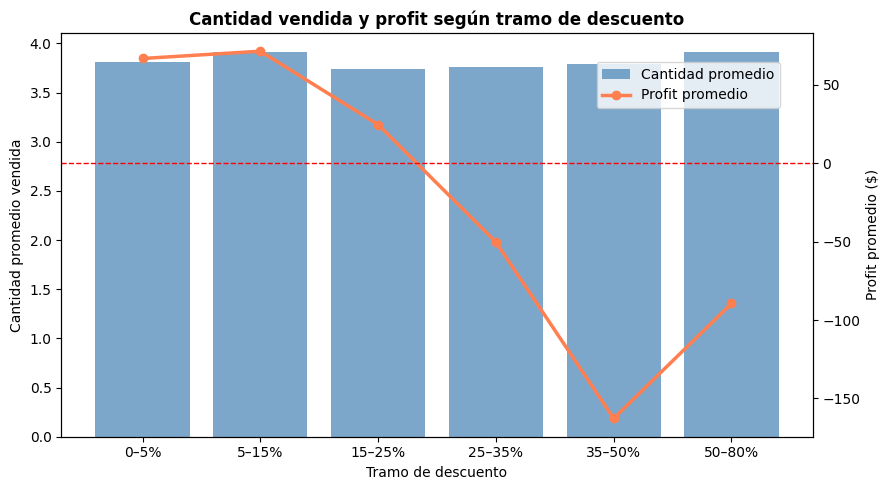

In [116]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(
    resumen_tramo['Tramo_descuento'].astype(str),
    resumen_tramo['Cantidad_prom'],
    color='steelblue',
    alpha=0.7,
    label='Cantidad promedio'
)
ax1.set_ylabel('Cantidad promedio vendida')
ax1.set_xlabel('Tramo de descuento')

ax2 = ax1.twinx()
ax2.plot(
    resumen_tramo['Tramo_descuento'].astype(str),
    resumen_tramo['Profit_prom'],
    color='coral',
    marker='o',
    linewidth=2.5,
    label='Profit promedio'
)
ax2.axhline(0, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Profit promedio ($)')

plt.title('Cantidad vendida y profit según tramo de descuento', fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

# 3.5. APLICACIÓN DE CONCEPTOS DE LA MATERIA

# Estrategia metodológica


**El análisis sigue una secuencia causal y progresiva:**

* A) Modelización económica: ajuste de regresiones polinómicas para
   Ingresos = f(Descuento), Costo = f(Descuento) y Beneficio = f(Descuento).
   Los modelos permiten extrapolar y encontrar el punto crítico analíticamente.

* B) Derivación del umbral: cálculo de la raíz de B(d) = 0 para identificar
   el nivel de descuento exacto a partir del cual el beneficio se vuelve negativo.***


# A) Modelización económica: Beneficio, Ingresos y Costo
 
 *Se ajustan regresiones polinómicas de grado 2 a los datos observados, usando el valor exacto de descuento como variable independiente. Esto permite obtener funciones continuas que capturan la tendencia general sin estar sujetas a la discretización por tramos.*

In [117]:

x          = resumen['Discount'].values
y_profit   = resumen['Profit_prom'].values
y_ingresos = resumen['Ventas_prom'].values
y_costo    = resumen['Costo_prom'].values

# Ajuste de coeficientes por Mínimos Cuadrados Ordinarios (OLS) para el ajuste polinómico de grado 2 (np.polyfit)
coef_profit   = np.polyfit(x, y_profit,   2)
coef_ingresos = np.polyfit(x, y_ingresos, 2)
coef_costo    = np.polyfit(x, y_costo,    2)

a, b, c = coef_profit

print("=" * 60)
print("MODELOS ECONÓMICOS (Regresión polinómica de grado 2)")
print("=" * 60)
print(f"Beneficio:  B(d) = {coef_profit[0]:.2f}·d² + {coef_profit[1]:.2f}·d + {coef_profit[2]:.2f}")
print(f"Ingresos:   I(d) = {coef_ingresos[0]:.2f}·d² + {coef_ingresos[1]:.2f}·d + {coef_ingresos[2]:.2f}")
print(f"Costo:      C(d) = {coef_costo[0]:.2f}·d² + {coef_costo[1]:.2f}·d + {coef_costo[2]:.2f}")



MODELOS ECONÓMICOS (Regresión polinómica de grado 2)
Beneficio:  B(d) = 470.74·d² + -481.41·d + 73.21
Ingresos:   I(d) = -1141.19·d² + 456.62·d + 284.19
Costo:      C(d) = -1611.93·d² + 938.03·d + 210.98


# B) Análisis del punto crítico mediante derivada e identificación del umbral

*La derivada primera B'(d) = 2a·d + b se iguala a cero para encontrar el vértice de la parábola. La condición de segundo orden (signo de 2a) determina si ese punto es máximo o mínimo.*

In [118]:
punto_critico     = -b / (2 * a)
segunda_derivada  = 2 * a

print("-" * 60)
print("ANÁLISIS DE LA FUNCIÓN DE BENEFICIO")
print("-" * 60)

if segunda_derivada < 0:
    print(f"  Curva cóncava (∩): máximo interno en d = {punto_critico:.2%}")
else:
    print(f"  Curva convexa (∪): el punto en d = {punto_critico:.2%} es un MÍNIMO")
    print(f"  → El beneficio se maximiza sin descuento (d = 0%)")

# Umbral de rentabilidad: primera raíz de B(d) = 0 en el rango [0, 1]
raices = np.roots([a, b, c])
raices_validas = sorted([r.real for r in raices if np.isreal(r) and 0 < r.real < 1])

if raices_validas:
    umbral_critico = raices_validas[0]   # primera raíz = primer cruce a negativo
    print(f"  Raíces de B(d) = 0 en [0,1]: {[f'{r:.2%}' for r in raices_validas]}")
    print(f"  ► Umbral crítico (B cruza a negativo): {umbral_critico:.2%}")
else:
    print("  No se encontró umbral crítico en el rango [0%, 100%].")
    umbral_critico = None

------------------------------------------------------------
ANÁLISIS DE LA FUNCIÓN DE BENEFICIO
------------------------------------------------------------
  Curva convexa (∪): el punto en d = 51.13% es un MÍNIMO
  → El beneficio se maximiza sin descuento (d = 0%)
  Raíces de B(d) = 0 en [0,1]: ['18.58%', '83.68%']
  ► Umbral crítico (B cruza a negativo): 18.58%


# Gráfico final: Curvas de Beneficio, Ingreso y Costo vs. Descuento

*Este gráfico es el núcleo del análisis económico. Muestra simultáneamente las tres curvas para visualizar cómo el aumento del descuento desplaza los ingresos hacia abajo y los costos relativos al alza, resultando en
un beneficio que cruza cero en el umbral crítico identificado.*

**Este análisis nos revela nuestro Punto de Equilibrio o, en el contexto de nuestra investigación, el "punto de no retorno". No estamos buscando aquí el fondo del pozo (la máxima pérdida), sino el momento exacto en el que cruzamos la línea roja. Matemáticamente, es el punto donde la curva de Ingresos Totales es finalmente alcanzada y devorada por la curva de Costos. En términos de negocio, representa la frontera de la viabilidad comercial: antes de este porcentaje de descuento, la empresa gana cada vez menos plata, pero al menos la transacción sigue sumando valor positivo; sin embargo, al cruzar esta frontera, el negocio ya no tiene sentido. A partir de aquí, el descuento es tan agresivo que Superstore literalmente "paga por vender", destruyendo el margen de rentabilidad y convirtiendo cada venta adicional en una pérdida neta directa.**

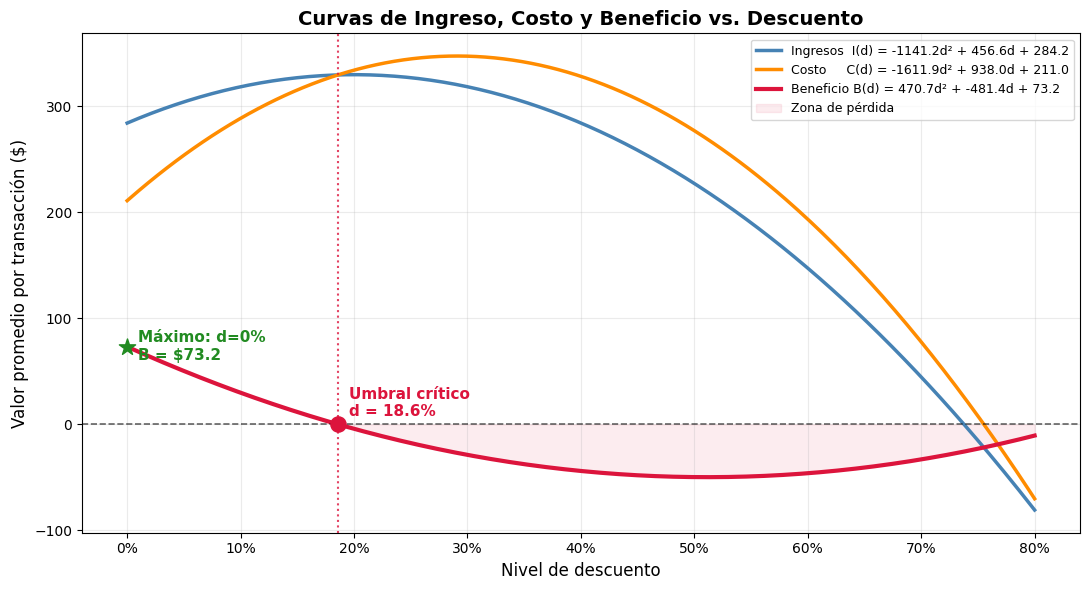

In [119]:

d_line = np.linspace(0, 0.8, 300)

b_line = np.polyval(coef_profit,   d_line)
i_line = np.polyval(coef_ingresos, d_line)
c_line = np.polyval(coef_costo,    d_line)

plt.figure(figsize=(11, 6))

# Curva de Ingresos
plt.plot(d_line, i_line, color='steelblue',  linewidth=2.5,
         label=f'Ingresos  I(d) = {coef_ingresos[0]:.1f}d² + {coef_ingresos[1]:.1f}d + {coef_ingresos[2]:.1f}')

# Curva de Costo
plt.plot(d_line, c_line, color='darkorange', linewidth=2.5,
         label=f'Costo     C(d) = {coef_costo[0]:.1f}d² + {coef_costo[1]:.1f}d + {coef_costo[2]:.1f}')

# Curva de Beneficio
plt.plot(d_line, b_line, color='crimson',    linewidth=3,
         label=f'Beneficio B(d) = {a:.1f}d² + {b:.1f}d + {c:.1f}')

# Línea de equilibrio
plt.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)

# Marcador: umbral crítico (B = 0)
if umbral_critico:
    plt.axvline(umbral_critico, color='crimson', linewidth=1.5,
                linestyle=':', alpha=0.8)
    plt.scatter([umbral_critico], [0], color='crimson', s=120, zorder=6)
    plt.text(
        umbral_critico + 0.01, 5,
        f'Umbral crítico\nd = {umbral_critico:.1%}',
        color='crimson', fontsize=11, fontweight='bold', va='bottom'
    )

# Marcador: beneficio máximo en d = 0
b_en_0 = np.polyval(coef_profit, 0)
plt.scatter([0], [b_en_0], color='forestgreen', s=150, marker='*', zorder=6)
plt.text(
    0.01, b_en_0,
    f'Máximo: d=0%\nB = ${b_en_0:.1f}',
    color='forestgreen', fontsize=11, fontweight='bold', va='center'
)

# Zona de pérdida (sombreado)
if umbral_critico:
    zona_x = d_line[d_line >= umbral_critico]
    zona_b = np.polyval(coef_profit, zona_x)
    plt.fill_between(zona_x, zona_b, 0,
                     where=(zona_b < 0),
                     color='crimson', alpha=0.08,
                     label='Zona de pérdida')

plt.title('Curvas de Ingreso, Costo y Beneficio vs. Descuento',
          fontsize=14, fontweight='bold')
plt.xlabel('Nivel de descuento', fontsize=12)
plt.ylabel('Valor promedio por transacción ($)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.legend(fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# CONCLUSIÓN

**El análisis de regresión polinómica sobre los niveles distintos
de descuento observados en el dataset indica que:**

  • El beneficio promedio por transacción es positivo para descuentos
    inferiores a 18.6%.

  • A partir de 18.6% de descuento el beneficio se vuelve
    negativo: el incremento en ingresos ya no alcanza a cubrir la
    caída del margen, destruyendo valor en cada venta.

  • Las curvas de Ingreso y Costo convergen en ese punto: I(d) = C(d),
    es decir, la empresa vende al costo sin generar ganancia.

  • El beneficio se maximiza en d = 0% ($73.2 promedio por orden),
    confirmando que la política de descuentos, en promedio, reduce
    la rentabilidad de la empresa independientemente del volumen generado.


# ANALISIS SUPLEMENTARIOS

*Marginalidad: la velocidad del negocio*

Este analisis suplementario nos muestra la cara de la otra moneda. No nos da directamente los valores economicos que nos permiten tomar una decisión concreta, pero confirma dentro de la logica economica nuestra suposición principal, luego confirmada por los datos: Que la velocidad a la que los descuentos "hacen viajar" al beneficio tiende hacia abajo porque los cambios marginales que se pueden realizar adentro de los costos y los ingresos, con respecto a los descuentos, viajan a unas tasas tales donde el costo "va más rapido" que los ingresos, hasta llegar al fin al punto donde ambos viajan igual, eel 55% que veremos en el grafico más adelante.

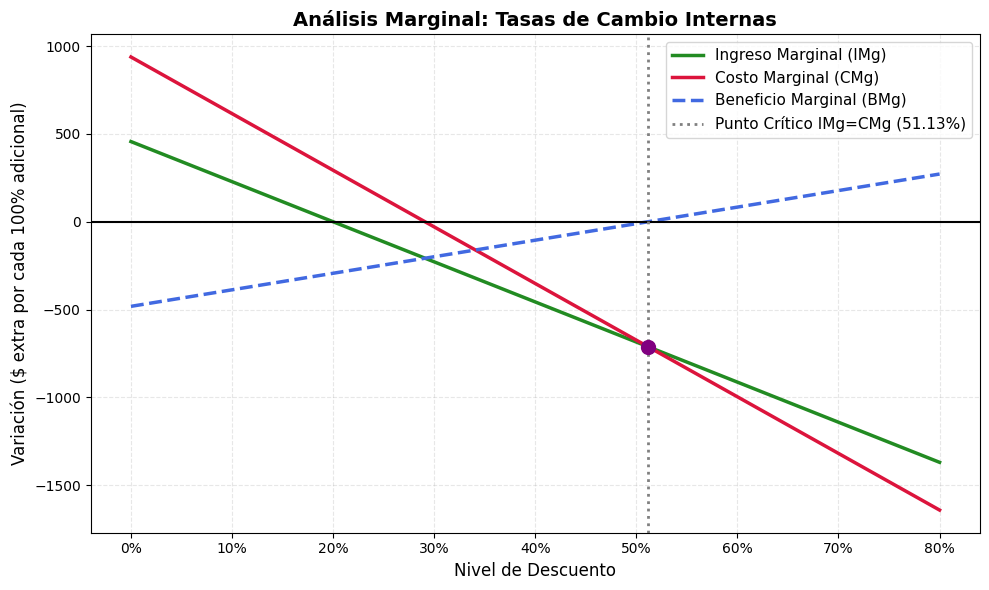

In [120]:
# 1. Aseguramos tener los coeficientes de Ingreso y Costo (grado 2)
# Tomamos las variables desde el DataFrame 'resumen' que usaste antes
x_desc = resumen['Discount']
y_ingreso = resumen['Ventas_prom']
y_costo = resumen['Costo_prom']     

coef_ingreso = np.polyfit(x_desc, y_ingreso, 2)
coef_costo = np.polyfit(x_desc, y_costo, 2)

# Nota: Asumimos que los coeficientes del Beneficio ya están en las variables 'a', 'b' y 'c' 
# desde tu celda anterior.

# 2. Generamos los datos continuos para el eje X (de 0 a 80% de descuento)
d_line = np.linspace(0, 0.8, 100)

# 3. Calculamos las Derivadas: f'(x) = 2*coef_a*x + coef_b
img_line = 2 * coef_ingreso[0] * d_line + coef_ingreso[1]
cmg_line = 2 * coef_costo[0] * d_line + coef_costo[1]
bmg_line = 2 * a * d_line + b  # Beneficio Marginal

# 4. Configuración del gráfico
plt.figure(figsize=(10, 6))

# Graficamos las tres líneas rectas (Tasa de Cambio)
plt.plot(d_line, img_line, color='forestgreen', linewidth=2.5, label='Ingreso Marginal (IMg)')
plt.plot(d_line, cmg_line, color='crimson', linewidth=2.5, label='Costo Marginal (CMg)')
plt.plot(d_line, bmg_line, color='royalblue', linewidth=2.5, linestyle='--', label='Beneficio Marginal (BMg)')

# Línea de Cero
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

# Marcador del punto de cruce crítico (donde IMg = CMg y BMg = 0)
punto_critico_x = -b / (2 * a)
plt.axvline(punto_critico_x, color='gray', linestyle=':', linewidth=2, label=f'Punto Crítico IMg=CMg ({punto_critico_x:.2%})')

# Detalle estético: un punto exacto en la "X" donde se cruzan Costo e Ingreso Marginal
punto_critico_y = 2 * coef_ingreso[0] * punto_critico_x + coef_ingreso[1]
plt.scatter([punto_critico_x], [punto_critico_y], color='purple', s=100, zorder=5)

# Títulos y etiquetas
plt.title('Análisis Marginal: Tasas de Cambio Internas', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Descuento', fontsize=12)
plt.ylabel('Variación ($ extra por cada 100% adicional)', fontsize=12)

# Formatear el eje X para que se vea como porcentaje
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Mostramos el gráfico
plt.show()

*Analisis por producto*

Como bonus track a nuestra investigación, descubrimos que Superstore no debería tener una única regla de descuentos para toda la empresa. Muebles tiene un margen tan fino que no tolera casi ningún descuento, mientras que Tecnología tiene 'espalda' suficiente para soportar promociones más agresivas sin entrar en pérdidas rojas. Sugerimos migrar de una política de descuentos global a una política segmentada.

ESTE ANALISIS NO FUE EL PRINCIPAL PORQUE PRIMERO DEBIAMOS VER LA TENDENCIA MACRO DE LA EMPRESA PARA VER SI ERA O NO VALIOSO REPLICAR PARA CADA SECTOR DE BIENES ESPECIFICO. CREEMOS QUE CON EL ANALISIS ANTERIOR, SE PODRÍA AVANZAR TRANQUILAMENTE A UN ANALISIS POR PRODUCTOS Y SECTOR.

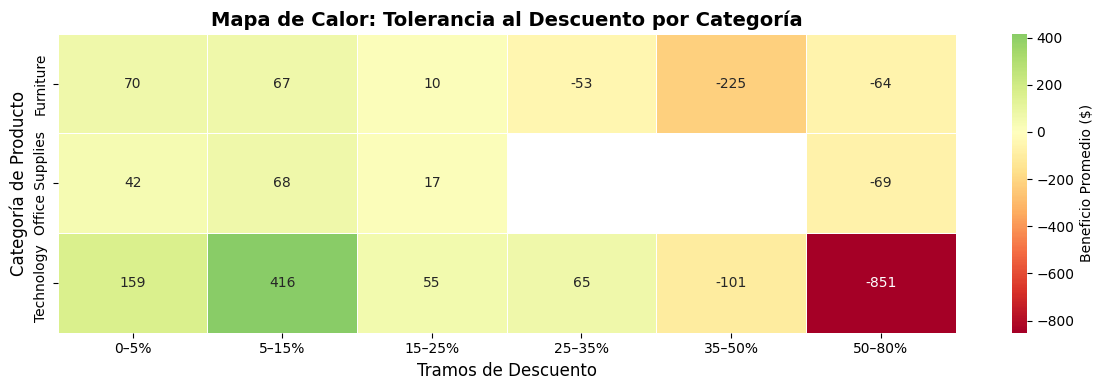

In [121]:

# 1. Transformamos la tabla profit_por_categoría en una matriz (Pivot) para graficarla
matriz_profit = profit_por_categoria.pivot(index='Category', columns='Tramo_descuento', values='Profit')

# 2. Creamos un Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 4))
sns.heatmap(matriz_profit, 
            annot=True,          # Muestra los números adentro
            fmt=".0f",           # Sin decimales para no ensuciar la vista
            cmap="RdYlGn",       # Rojo (pérdida), Amarillo (neutro), Verde (ganancia)
            center=0,            # Forzamos que el color neutro sea exactamente el $0
            linewidths=0.5, 
            cbar_kws={'label': 'Beneficio Promedio ($)'})

plt.title('Mapa de Calor: Tolerancia al Descuento por Categoría', fontsize=14, fontweight='bold')
plt.xlabel('Tramos de Descuento', fontsize=12)
plt.ylabel('Categoría de Producto', fontsize=12)
plt.tight_layout()
plt.show()